In [15]:
import pandas as pd
import numpy as np
import time
import joblib
import os
import json
import xgboost as xgb
import warnings
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print("--- 1. Loading Machine Learning Dataset ---")
# Load the leak-proof, feature-engineered dataset
df = pd.read_parquet('../data/processed/train_data_ml_ready.parquet')

--- 1. Loading Machine Learning Dataset ---


In [3]:
y = df['target']
X = df.drop(columns=['target', 'customer_ID'])

In [4]:
print("\n--- 2. Linear Data Preparation (The -999 Trap) ---")
# Scikit-Learn Logistic Regression cannot handle -999.0 outliers or NaNs.
# Because we robust-scaled earlier, the median of our features is ~0.0.
# Replacing -999.0 with 0.0 safely acts as Median Imputation.
X_linear = X.replace(-999.0, 0.0).fillna(0.0)

print("\n--- 3. Training Logistic Regression Baseline ---")
# 5-Fold Cross Validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Arrays to hold our benchmark metrics
oof_preds = np.zeros(len(X_linear))
fold_aucs = []

# Initialize model (C=0.1 adds slight regularization to prevent overfitting on 800+ cols)
log_model = LogisticRegression(max_iter=1000, C=0.1, random_state=42, n_jobs=-1)

start_time = time.time()

fold = 1
for train_idx, val_idx in skf.split(X_linear, y):
    # Split data
    X_train, X_val = X_linear.iloc[train_idx], X_linear.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Train model
    log_model.fit(X_train, y_train)
    
    # Predict probabilities (we want the probability of Default, which is class 1)
    val_preds = log_model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    
    # Calculate Fold AUC
    fold_auc = roc_auc_score(y_val, val_preds)
    fold_aucs.append(fold_auc)
    print(f"Fold {fold} AUC: {fold_auc:.4f}")
    
    fold += 1

total_time = time.time() - start_time
mean_auc = np.mean(fold_aucs)


--- 2. Linear Data Preparation (The -999 Trap) ---

--- 3. Training Logistic Regression Baseline ---


c:\Users\santo\Documents\Evoastra Ventures\Amex\amex_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\santo\Documents\Evoastra Ventures\Amex\amex_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1 AUC: 0.9066


c:\Users\santo\Documents\Evoastra Ventures\Amex\amex_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\santo\Documents\Evoastra Ventures\Amex\amex_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2 AUC: 0.9007


...

Fold 3 AUC: 0.9000


c:\Users\santo\Documents\Evoastra Ventures\Amex\amex_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\santo\Documents\Evoastra Ventures\Amex\amex_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 4 AUC: 0.8994


c:\Users\santo\Documents\Evoastra Ventures\Amex\amex_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\santo\Documents\Evoastra Ventures\Amex\amex_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 5 AUC: 0.8974


In [5]:
print("\n--- 4. Benchmark Performance & Speed ---")
print(f" Cross-Validated Mean AUC: {mean_auc:.4f}")
print(f" Total Training Time (5 Folds): {total_time / 60:.2f} minutes")


--- 4. Benchmark Performance & Speed ---
 Cross-Validated Mean AUC: 0.9008
 Total Training Time (5 Folds): 16.84 minutes



--- 5. Coefficient Clarity (Feature Importance) ---


C:\Users\santo\AppData\Local\Temp\ipykernel_21004\2556691707.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_risks, x='Coefficient', y='Feature', ax=axes[0], palette='Reds_r')
C:\Users\santo\AppData\Local\Temp\ipykernel_21004\2556691707.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_safeties, x='Coefficient', y='Feature', ax=axes[1], palette='Blues_r')


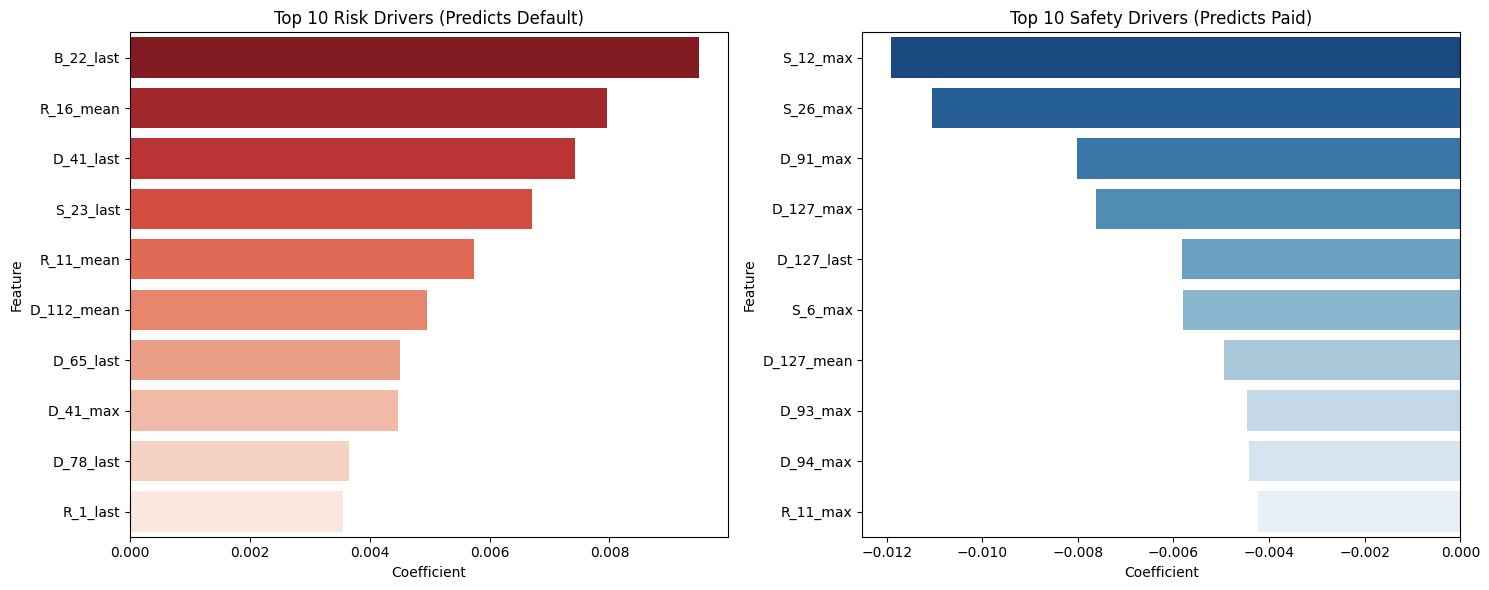

In [11]:
print("\n--- 5. Coefficient Clarity (Feature Importance) ---")
# We extract the coefficients from the final trained fold to understand what drives the model
coefficients = pd.DataFrame({
    'Feature': X_linear.columns,
    'Coefficient': log_model.coef_[0]
})

# Sort by absolute magnitude to find the most impactful features
coefficients['Abs_Magnitude'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Magnitude', ascending=False)

# Display Top 10 Red Flags (Positive) and Top 10 Safety Nets (Negative)
top_risks = coefficients.sort_values(by='Coefficient', ascending=False).head(10)
top_safeties = coefficients.sort_values(by='Coefficient', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Top Risk Factors
sns.barplot(data=top_risks, x='Coefficient', y='Feature', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Risk Drivers (Predicts Default)')

# Plot Top Safety Factors
sns.barplot(data=top_safeties, x='Coefficient', y='Feature', ax=axes[1], palette='Blues_r')
axes[1].set_title('Top 10 Safety Drivers (Predicts Paid)')

plt.tight_layout()
plt.show()

In [10]:
print("--- 6. Saving Trained Model ---")

# Ensure the model_save directory exists so we don't get a FileNotFoundError
save_dir = '../model_save'
os.makedirs(save_dir, exist_ok=True)

# Define the file path
model_path = os.path.join(save_dir, 'logistic_baseline_model.joblib')

# Serialize and save the model
joblib.dump(log_model, model_path)

print(f" Baseline model successfully saved at: {model_path}")

# Quick tip: If you ever need to load this model in a different notebook, you just use:
# loaded_model = joblib.load(model_path)

--- 6. Saving Trained Model ---
 Baseline model successfully saved at: ../model_save\logistic_baseline_model.joblib


In [13]:
print("\n--- 2. Training Pruned Decision Tree ---")
# 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# PRUNING: This is the most critical step. 
# Without max_depth, a tree on 458k rows will grow thousands of levels deep, overfit, and become unreadable.
# max_depth=4 restricts it to 4 "IF/THEN" questions.
# min_samples_leaf=2000 prevents the tree from making rules for tiny, noisy groups of customers.
tree_model = DecisionTreeClassifier(
    max_depth=4, 
    min_samples_leaf=2000, 
    random_state=42
)

fold_aucs = []
start_time = time.time()

fold = 1
for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    tree_model.fit(X_train, y_train)
    
    # Predict probabilities for AUC calculation
    val_preds = tree_model.predict_proba(X_val)[:, 1]
    
    fold_auc = roc_auc_score(y_val, val_preds)
    fold_aucs.append(fold_auc)
    print(f"Fold {fold} AUC: {fold_auc:.4f}")
    
    fold += 1

total_time = time.time() - start_time
mean_auc = np.mean(fold_aucs)


--- 2. Training Pruned Decision Tree ---
Fold 1 AUC: 0.9268
Fold 2 AUC: 0.9226
Fold 3 AUC: 0.9219
Fold 4 AUC: 0.9255
Fold 5 AUC: 0.9219


In [14]:
print("\n--- 3. Benchmark Performance & Speed ---")
print(f" Cross-Validated Mean AUC: {mean_auc:.4f}")
print(f"⏱ Total Training Time (5 Folds): {total_time / 60:.2f} minutes")


--- 3. Benchmark Performance & Speed ---
 Cross-Validated Mean AUC: 0.9237
⏱ Total Training Time (5 Folds): 9.02 minutes


In [15]:
print("\n--- 4. Transparent Path Comparison (The Rules) ---")
# Extract the IF/THEN text rules from the tree trained on the final fold
tree_rules = export_text(tree_model, feature_names=list(X.columns))
print("Decision Paths (Left = True, Right = False):")
print("-" * 50)
print(tree_rules)


--- 4. Transparent Path Comparison (The Rules) ---
Decision Paths (Left = True, Right = False):
--------------------------------------------------
|--- P_2_last <= -0.46
|   |--- FE_Payment_Risk_Interaction_last <= -1.06
|   |   |--- R_1_last <= 44.09
|   |   |   |--- FE_Delinquency_Severity_last <= 3.38
|   |   |   |   |--- class: 1
|   |   |   |--- FE_Delinquency_Severity_last >  3.38
|   |   |   |   |--- class: 1
|   |   |--- R_1_last >  44.09
|   |   |   |--- D_39_last <= 3.02
|   |   |   |   |--- class: 1
|   |   |   |--- D_39_last >  3.02
|   |   |   |   |--- class: 1
|   |--- FE_Payment_Risk_Interaction_last >  -1.06
|   |   |--- FE_Delinquency_Severity_last <= 3.14
|   |   |   |--- anomaly_score_last <= 0.14
|   |   |   |   |--- class: 0
|   |   |   |--- anomaly_score_last >  0.14
|   |   |   |   |--- class: 0
|   |   |--- FE_Delinquency_Severity_last >  3.14
|   |   |   |--- R_2_last <= 0.91
|   |   |   |   |--- class: 1
|   |   |   |--- R_2_last >  0.91
|   |   |   |   |--- 

1. The Root Node (The Most Important Rule)
Look at the very first split at the top, aligned perfectly to the left:

|--- P_2_last <= -0.46

|--- P_2_last >  -0.46

The tree determined that out of all 800+ features, a customer's most recent Payment behavior (P_2_last) is the single greatest divider between safe and risky customers.

If their score is extremely low (<= -0.46), they go down the top half of the tree (which is mostly filled with class: 1 defaults).

If their score is higher (> -0.46), they go down the bottom half (which is mostly filled with class: 0 safe payers).

2. Tracing a "High Risk" Path (Class 1)
Let’s trace the worst-case scenario. Read the top few lines like a staircase, adding the word "AND" at each step:

IF P_2_last <= -0.46 (They have poor payment history)

AND FE_Payment_Risk_Interaction_last <= -1.06 (Our custom risk interaction feature is flashing red)

AND R_1_last <= 44.09 (Risk factor 1 is within this specific threshold)

THEN class: 1 (Predict Default)

Note: Notice how our custom engineered feature (FE_Payment_Risk) was the very second question the tree asked? That proves your feature engineering was a massive success! The model found your custom math more useful than the raw Amex data.

3. Tracing a "Safe" Path (Class 0)
Now let's look at the bottom half of the tree:

IF P_2_last > -0.46 (They have decent payment history)

AND FE_Payment_Risk_Interaction_last > -0.10 (Our custom interaction says they are safe)

AND B_1_last > 0.87 (Their Balance is high)

AND FE_Pay_to_Balance_Ratio_last > 0.03 (BUT our custom ratio shows they are paying off that balance!)

THEN class: 0 (Predict Safe)

4. Why are some rules "redundant"?
You might have noticed something strange. Look at this block:

|   |   |--- D_39_last <= 3.02
|   |   |   |--- class: 1
|   |   |--- D_39_last >  3.02
|   |   |   |--- class: 1

It asks a question about D_39_last, but both answers result in class: 1. Why?

Because the Decision Tree is actually calculating probabilities behind the scenes.

If D_39_last <= 3.02, maybe the probability of default is 60%.

If D_39_last > 3.02, maybe the probability of default is 95%.

Because both probabilities are over 50%, the text summary just prints class: 1 for both. But the tree splits them because a 95% certainty is mathematically different from a 60% certainty when it calculates its final AUC score.

In [16]:
print("\n--- 5. Saving Trained Model ---")
save_dir = '../model_save'
os.makedirs(save_dir, exist_ok=True)
model_path = os.path.join(save_dir, 'decision_tree_pruned.joblib')
joblib.dump(tree_model, model_path)
print(f" Pruned Decision Tree model saved at: {model_path}")


--- 5. Saving Trained Model ---
 Pruned Decision Tree model saved at: ../model_save\decision_tree_pruned.joblib


In [6]:
print("\n--- 2. Configuring Stable XGBoost Engine ---")
# Calculate the exact imbalance ratio for scale_pos_weight
# (Count of Negative Class / Count of Positive Class)
# For Amex, this usually evaluates to roughly 3.0
imbalance_ratio = (len(y) - y.sum()) / y.sum()
print(f"Detected Class Imbalance. Setting scale_pos_weight to: {imbalance_ratio:.2f}")

# XGBoost Parameters focused on Stability and Generalization
xgb_params = {
    'n_estimators': 2000,           # High tree count, we will rely on early stopping
    'learning_rate': 0.03,          # Slow, stable learning steps
    'max_depth': 6,                 # Deep enough for complex patterns, shallow enough to prevent overfitting
    'subsample': 0.8,               # Randomly sample 80% of rows per tree (prevents overfitting)
    'colsample_bytree': 0.8,        # Randomly sample 80% of features per tree (forces feature diversity)
    'tree_method': 'hist',          # Histogram binning (massive speed boost, similar to LightGBM)
    'scale_pos_weight': imbalance_ratio, # Imbalance-aware penalization
    'missing': -999.0,              # CRITICAL: Tell XGBoost how to natively route missing data
    'device': 'cuda',  # <--- This triggers the GPU in older versions
    'random_state': 42,
    'n_jobs': -1                    # Use all CPU cores
}

xgb_model = xgb.XGBClassifier(**xgb_params)


--- 2. Configuring Stable XGBoost Engine ---
Detected Class Imbalance. Setting scale_pos_weight to: 2.86


In [7]:
print("\n--- 3. Training Primary XGBoost Model ---")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
fold_aucs = []
start_time = time.time()

fold = 1
for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # We use eval_set for Early Stopping. 
    # If the validation AUC doesn't improve for 100 rounds, the model stops early to prevent overfitting.
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=100, # Print progress every 100 trees
    )
    
    # Predict probabilities on the validation fold
    # Best_iteration ensures we use the exact tree where the model peaked before early stopping
    val_preds = xgb_model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    
    fold_auc = roc_auc_score(y_val, val_preds)
    fold_aucs.append(fold_auc)
    print(f" Fold {fold} AUC: {fold_auc:.4f}\n")
    
    fold += 1

total_time = time.time() - start_time
mean_auc = np.mean(fold_aucs)

print("--- 4. Final Benchmark Performance ---")
print(f" Cross-Validated Mean AUC: {mean_auc:.4f}")
print(f" Total Training Time: {total_time / 60:.2f} minutes")


--- 3. Training Primary XGBoost Model ---
[0]	validation_0-logloss:0.67478
[100]	validation_0-logloss:0.28677
[200]	validation_0-logloss:0.26327
[300]	validation_0-logloss:0.25676
[400]	validation_0-logloss:0.25276
[500]	validation_0-logloss:0.25064
[600]	validation_0-logloss:0.24912
[700]	validation_0-logloss:0.24788
[800]	validation_0-logloss:0.24667
[900]	validation_0-logloss:0.24552
[1000]	validation_0-logloss:0.24464
[1100]	validation_0-logloss:0.24392
[1200]	validation_0-logloss:0.24309
[1300]	validation_0-logloss:0.24236
[1400]	validation_0-logloss:0.24156
[1500]	validation_0-logloss:0.24096
[1600]	validation_0-logloss:0.24042
[1700]	validation_0-logloss:0.23979
[1800]	validation_0-logloss:0.23912
[1900]	validation_0-logloss:0.23894
[1999]	validation_0-logloss:0.23850


c:\Users\santo\Documents\Evoastra Ventures\Amex\amex_env\Lib\site-packages\xgboost\core.py:751: UserWarning: [14:57:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


 Fold 1 AUC: 0.9611

[0]	validation_0-logloss:0.67485
[100]	validation_0-logloss:0.29061
[200]	validation_0-logloss:0.26888
[300]	validation_0-logloss:0.26224
[400]	validation_0-logloss:0.25843
[500]	validation_0-logloss:0.25586
[600]	validation_0-logloss:0.25402
[700]	validation_0-logloss:0.25254
[800]	validation_0-logloss:0.25148
[900]	validation_0-logloss:0.25049
[1000]	validation_0-logloss:0.24953
[1100]	validation_0-logloss:0.24868
[1200]	validation_0-logloss:0.24742
[1300]	validation_0-logloss:0.24663
[1400]	validation_0-logloss:0.24596
[1500]	validation_0-logloss:0.24531
[1600]	validation_0-logloss:0.24471
[1700]	validation_0-logloss:0.24400
[1800]	validation_0-logloss:0.24334
[1900]	validation_0-logloss:0.24286
[1999]	validation_0-logloss:0.24190
 Fold 2 AUC: 0.9603

[0]	validation_0-logloss:0.67484
[100]	validation_0-logloss:0.28972
[200]	validation_0-logloss:0.26780
[300]	validation_0-logloss:0.26095
[400]	validation_0-logloss:0.25740
[500]	validation_0-logloss:0.25473
[600]	

In [8]:
print("\n--- 5. Saving Primary Model ---")
save_dir = '../model_save'
os.makedirs(save_dir, exist_ok=True)
model_path = os.path.join(save_dir, 'xgboost_primary.joblib')
joblib.dump(xgb_model, model_path)
print(f" XGBoost model successfully locked and saved at: {model_path}")


--- 5. Saving Primary Model ---
 XGBoost model successfully locked and saved at: ../model_save\xgboost_primary.joblib


In [9]:
# Suppress warnings for clean output during the loop
warnings.filterwarnings('ignore')

print("\n--- 2. Defining the Bayesian Search Space ---")
# hp.quniform: Quantized uniform (returns integers like 3, 4, 5)
# hp.uniform: Returns floats between the two bounds
space = {
    'max_depth': hp.quniform('max_depth', 3, 9, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.15),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0.0, 10.0),    # L1 Regularization
    'reg_lambda': hp.uniform('reg_lambda', 0.0, 10.0)   # L2 Regularization
}

print("\n--- 3. Building the Objective Engine ---")
# Hyperopt tries to MINIMIZE the objective. Since we want a HIGH AUC, 
# we return the negative AUC (-mean_auc).
def objective(params):
    # Ensure integer parameters are strictly cast to int
    params['max_depth'] = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])
    
    # Inject our locked stability parameters
    params['tree_method'] = 'hist'
    params['device'] = 'cuda'
    params['missing'] = -999.0
    params['scale_pos_weight'] = imbalance_ratio
    params['n_jobs'] = -1
    params['random_state'] = 42
    
    # We set n_estimators artificially high because we rely on early stopping
    params['n_estimators'] = 2000
    
    # Use 3 Folds instead of 5 during tuning to save massive amounts of time
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    fold_aucs = []
    
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = xgb.XGBClassifier(**params)
        
        # Train with early stopping: if validation AUC stops improving for 50 trees, stop.
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False # Keep it silent so we don't flood the console
        )
        
        preds = model.predict_proba(X_val)[:, 1]
        fold_aucs.append(roc_auc_score(y_val, preds))
        
    mean_auc = np.mean(fold_aucs)
    
    # Hyperopt requires this exact dictionary structure back
    return {'loss': -mean_auc, 'status': STATUS_OK, 'params': params}


--- 2. Defining the Bayesian Search Space ---

--- 3. Building the Objective Engine ---


In [10]:
print("\n--- 4. Executing Hyperopt Search ---")
print("Launching Bayesian Search... Grab a coffee, this will take some time.")
start_time = time.time()

# Trials object stores the history of what parameter combos worked or failed
trials = Trials()

# fmin runs the actual search. max_evals=30 means it will test 30 different parameter combinations.
best_raw = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest, # TPE is the Bayesian algorithm
    max_evals=30,     # Increase this to 50 or 100 if you have hours to spare
    trials=trials,
    rstate=np.random.default_rng(42) # Fixed seed for reproducibility
)

total_time = time.time() - start_time


--- 4. Executing Hyperopt Search ---
Launching Bayesian Search... Grab a coffee, this will take some time.
100%|██████████| 30/30 [14:40:00<00:00, 1760.03s/trial, best loss: -0.9610042689556849]  


In [12]:

print("\n--- 5. Extracting Optimal Architecture ---")
# 1. Clean the raw output from memory into a formatted dictionary
best_params = {
    'max_depth': int(best_raw['max_depth']),
    'min_child_weight': int(best_raw['min_child_weight']),
    'learning_rate': round(best_raw['learning_rate'], 4),
    'subsample': round(best_raw['subsample'], 4),
    'colsample_bytree': round(best_raw['colsample_bytree'], 4),
    'reg_alpha': round(best_raw['reg_alpha'], 4),
    'reg_lambda': round(best_raw['reg_lambda'], 4),
}

print("\n BEST PARAMETERS FOUND:")
for key, value in best_params.items():
    print(f"  {key}: {value}")




--- 5. Extracting Optimal Architecture ---

 BEST PARAMETERS FOUND:
  max_depth: 7
  min_child_weight: 8
  learning_rate: 0.018
  subsample: 0.8424
  colsample_bytree: 0.744
  reg_alpha: 9.9856
  reg_lambda: 6.7771


In [13]:
print("\n--- 6. The Safety Net: Saving the Results ---")
save_dir = '../model_save'
os.makedirs(save_dir, exist_ok=True)

# 2. Save the parameters to a JSON file
params_path = os.path.join(save_dir, 'hyperopt_best_params.json')
with open(params_path, 'w') as f:
    json.dump(best_params, f, indent=4)
print(f" Optimal parameters locked and saved at: {params_path}")

# 3. Prepare the final configuration (Merging best params with GPU/Stability settings)
final_params = best_params.copy()
final_params['tree_method'] = 'hist'
final_params['device'] = 'cuda'        # Keep the GPU engaged!
final_params['missing'] = -999.0
final_params['scale_pos_weight'] = imbalance_ratio
final_params['random_state'] = 42
final_params['n_estimators'] = 1500    # Safe, static estimator count for full data

print(" Training the final optimized model on the full dataset...")
final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X, y)

# 4. Save the actual trained model
model_path = os.path.join(save_dir, 'xgboost_optimized_final.joblib')
joblib.dump(final_model, model_path)
print(f" Final Optimized Model successfully saved to disk at: {model_path}")


--- 6. The Safety Net: Saving the Results ---
 Optimal parameters locked and saved at: ../model_save\hyperopt_best_params.json
 Training the final optimized model on the full dataset...
 Final Optimized Model successfully saved to disk at: ../model_save\xgboost_optimized_final.joblib


Total Features: 710
Raw Features: 690 | Engineered Features: 20

--- 2. Running the Ablation Study ---
 1. Vanilla XGBoost (Raw Data) trained in 157.3s -> AUC: 0.9608
 2. XGBoost + Imbalance Weights trained in 156.9s -> AUC: 0.9608
 3. XGBoost + Imbalance + Feature Eng trained in 172.2s -> AUC: 0.9607

--- 3. Validation Performance Summary ---
                       Configuration  ROC_AUC   PR_AUC  Time (sec)
       1. Vanilla XGBoost (Raw Data) 0.960837 0.896568       157.3
      2. XGBoost + Imbalance Weights 0.960812 0.896668       156.9
3. XGBoost + Imbalance + Feature Eng 0.960750 0.896568       172.2

--- 4. Visualizing the Improvements ---


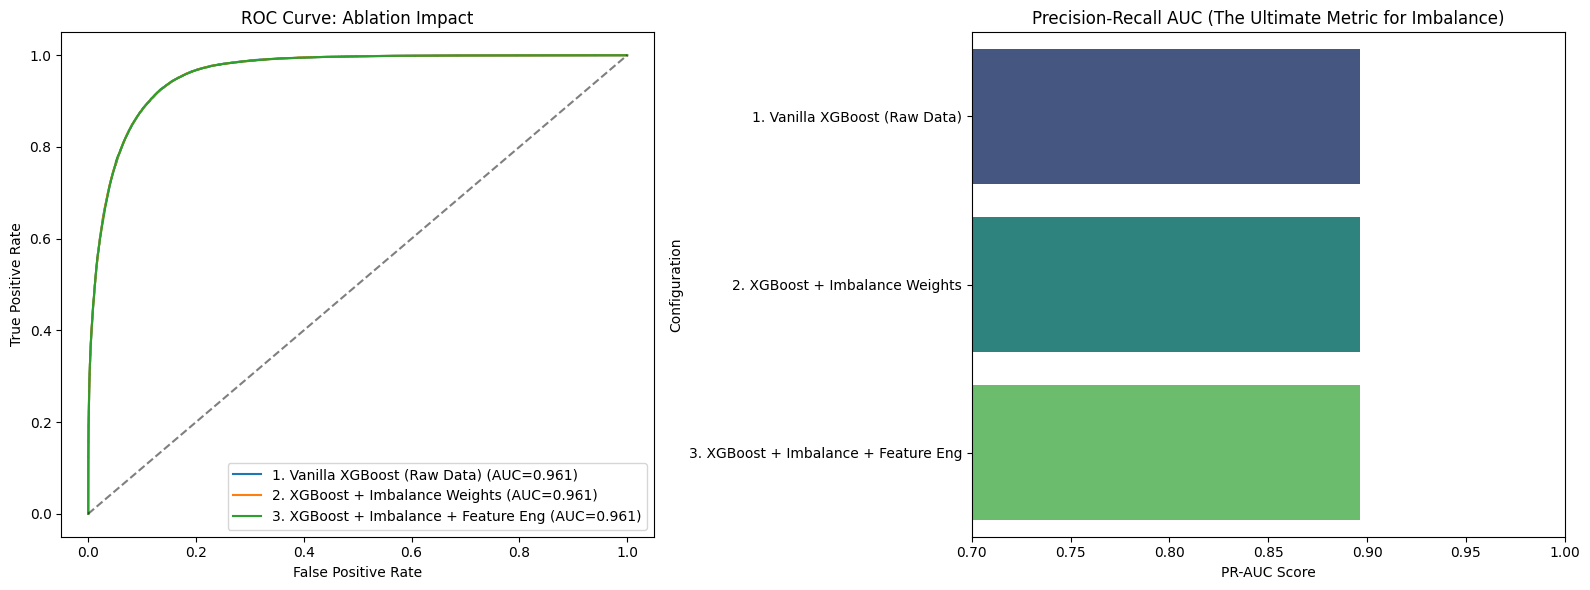

In [16]:
warnings.filterwarnings('ignore')

y = df['target']
X_full = df.drop(columns=['target', 'customer_ID'])

# Identify engineered features vs raw features
fe_cols = [col for col in X_full.columns if col.startswith('FE_')]
raw_cols = [col for col in X_full.columns if col not in fe_cols]

print(f"Total Features: {X_full.shape[1]}")
print(f"Raw Features: {len(raw_cols)} | Engineered Features: {len(fe_cols)}")

# Create a fast 20% holdout set for instant validation
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.20, stratify=y, random_state=42
)

# Create subsets for the ablation tests
X_train_raw = X_train_full[raw_cols]
X_test_raw = X_test_full[raw_cols]

imbalance_ratio = (len(y_train) - y_train.sum()) / y_train.sum()

print("\n--- 2. Running the Ablation Study ---")
results = []

# Base parameters for speed and consistency
base_params = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'tree_method': 'hist',
    'device': 'cuda', # Using GPU for instant results
    'missing': -999.0,
    'random_state': 42,
    'n_jobs': -1
}

def evaluate_model(name, X_tr, X_te, weights=1.0):
    start = time.time()
    params = base_params.copy()
    params['scale_pos_weight'] = weights
    
    model = xgb.XGBClassifier(**params)
    model.fit(X_tr, y_train, eval_set=[(X_te, y_test)], verbose=False)
    
    preds = model.predict_proba(X_te)[:, 1]
    
    auc = roc_auc_score(y_test, preds)
    pr_auc = average_precision_score(y_test, preds) # Crucial for imbalanced data
    
    results.append({
        'Configuration': name,
        'ROC_AUC': auc,
        'PR_AUC': pr_auc,
        'Time (sec)': round(time.time() - start, 1),
        'Predictions': preds # Saved for plotting
    })
    print(f" {name} trained in {round(time.time() - start, 1)}s -> AUC: {auc:.4f}")

# Test 1: The "Lazy" Data Scientist (Raw data, no imbalance correction)
evaluate_model("1. Vanilla XGBoost (Raw Data)", X_train_raw, X_test_raw, weights=1.0)

# Test 2: Imbalance Remediation Only
evaluate_model("2. XGBoost + Imbalance Weights", X_train_raw, X_test_raw, weights=imbalance_ratio)

# Test 3: The Full Arsenal (Your actual pipeline)
evaluate_model("3. XGBoost + Imbalance + Feature Eng", X_train_full, X_test_full, weights=imbalance_ratio)

print("\n--- 3. Validation Performance Summary ---")
results_df = pd.DataFrame(results).drop(columns=['Predictions'])
print(results_df.to_string(index=False))

print("\n--- 4. Visualizing the Improvements ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: ROC Curve Comparison
for res in results:
    fpr, tpr, _ = roc_curve(y_test, res['Predictions'])
    axes[0].plot(fpr, tpr, label=f"{res['Configuration']} (AUC={res['ROC_AUC']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curve: Ablation Impact')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Plot 2: Bar Chart of PR-AUC (Precision-Recall)
sns.barplot(data=results_df, y='Configuration', x='PR_AUC', ax=axes[1], palette='viridis')
axes[1].set_title('Precision-Recall AUC (The Ultimate Metric for Imbalance)')
axes[1].set_xlabel('PR-AUC Score')
axes[1].set_xlim(0.7, 1.0) # Zoomed in to show the exact delta

plt.tight_layout()
plt.show()